In [ ]:
Gastro-Competition: Multi-label calssification based on Transformers. The code is built upon : https://github.com/NielsRogge/Transformers-Tutorials/blob/master/SigLIP/Fine_tuning_SigLIP_and_friends_for_multi_label_image_classification.ipynb

## **Set-up environment**

In [1]:
#!pip install --upgrade transformers -q

In [1]:
import os
import cv2
import random
import torch
import numpy as np

from torch.utils.data import Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from PIL import Image

## **Data preprocessing**

In [2]:
#splite the training and testing path
current_path = os.getcwd()
print('cwd=',current_path)

train_size = 0.8
paths0 = []

path_to_subset = 'data'              #'../apparel-dataset'

# Load the array from the file
train_paths = np.load('train_path.npy')
#train_paths = train_paths[0]
train_labels = np.load('train_label.npy')
test_paths = np.load('val_path.npy')
#test_paths = test_paths[0]
test_labels = np.load('val_label.npy')
print(len(train_paths), len(train_labels), len(test_paths), len(test_labels))
print(train_paths[-1], train_labels[-1], test_paths[0],test_labels[0])

cwd= /mnt/e/Data/2026-RARE-Vision-Gastro/galar_dataset/notebooks
42234 42234 10890 10890
['data/Galar_Frames_51_to_60/56/frame_051199.PNG'] [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0] ['data/Galar_Frames_1_to_10/1/frame_000100.PNG'] [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [3]:
print("show sample of training path ",train_paths[-1])
print("Number of training data : ",len(train_paths))
print("Number of val data : ", len(test_paths))

show sample of training path  ['data/Galar_Frames_51_to_60/56/frame_051199.PNG']
Number of training data :  42234
Number of val data :  10890


path-name= data/Galar_Frames_51_to_60/56/frame_051199.PNG


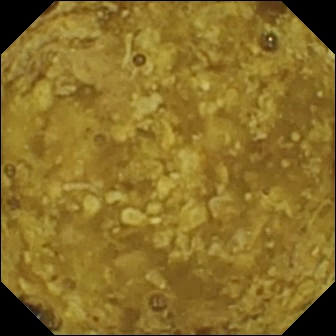

laebel= [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [4]:
#Displaying an image
 # get image
image_path = train_paths[-1][0]
print('path-name=', image_path)
image = Image.open(image_path).convert("RGB")
label = train_labels[-1]
display(image)
print('laebel=',label)

In [5]:
#Label and classes extraction
def labels(root):
  classes=[]
  lab=[]
  labels=[]
  for idx in range(len(root)):
    # get image
    image_path =root[idx]

    # get labels
    label = image_path.split(os.path.sep)[-2].split('_')
    lab.append(label)

  mlb = MultiLabelBinarizer()
  labels = mlb.fit_transform(lab)
  classes = mlb.classes_

  return labels,classes


In [6]:
#Label and classes extraction
classes = ['mouth','esophagus','stomach','smallintestine','colon',
         'z_line','pylorus','ileocecalvalve','activebleeding','angiectasia',
        'blood','erosion','erythema','hematin','lymphangioectasis',
        'polyp','ulcer']


In [7]:
#Show label and classes
m_labels = train_labels
print("labels encode :",m_labels)
print("Class Names :",classes)

labels encode : [[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Class Names : ['mouth', 'esophagus', 'stomach', 'smallintestine', 'colon', 'z_line', 'pylorus', 'ileocecalvalve', 'activebleeding', 'angiectasia', 'blood', 'erosion', 'erythema', 'hematin', 'lymphangioectasis', 'polyp', 'ulcer']


In [8]:
#Id to label and label to id for fine tune the model
id2label = {id: label for id, label in enumerate(classes)}
label2id = {v: k for k, v in id2label.items()}
print(id2label)
print(label2id)

{0: 'mouth', 1: 'esophagus', 2: 'stomach', 3: 'smallintestine', 4: 'colon', 5: 'z_line', 6: 'pylorus', 7: 'ileocecalvalve', 8: 'activebleeding', 9: 'angiectasia', 10: 'blood', 11: 'erosion', 12: 'erythema', 13: 'hematin', 14: 'lymphangioectasis', 15: 'polyp', 16: 'ulcer'}
{'mouth': 0, 'esophagus': 1, 'stomach': 2, 'smallintestine': 3, 'colon': 4, 'z_line': 5, 'pylorus': 6, 'ileocecalvalve': 7, 'activebleeding': 8, 'angiectasia': 9, 'blood': 10, 'erosion': 11, 'erythema': 12, 'hematin': 13, 'lymphangioectasis': 14, 'polyp': 15, 'ulcer': 16}


## **Create PyTorch Dataset**

In [9]:
class MultiLabelDataset(Dataset):
  def __init__(self, root, transform,labels):
    self.root = root
    self.transform = transform
    self.labels=labels

  def __getitem__(self, idx):
    # get image
    image_path = self.root[idx][0]      #was self.root[idx]
    image = Image.open(image_path).convert("RGB")

    # prepare image for the model
    pixel_values = self.transform(image)

    # get labels
    label = self.labels[idx].astype(np.float32)

    # turn into PyTorch tensor
    label = torch.from_numpy(label)

    return pixel_values,label


  def __len__(self):
    return len(self.root)

## **Model Load**

In [10]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from transformers import AutoModel, AutoProcessor

#select the pretraining model
model_id = "google/vit-base-patch16-224-in21k" # "google/siglip-so400m-patch14-384"
save_dir = "./pretrained/google/vit-base-patch16-224-in21k"
#save_dir = "fine_tuned_vit-base-patch16-224-in21k.pth"

#processor = AutoImageProcessor.from_pretrained(model_id, use_fast=True)
#model = AutoModelForImageClassification.from_pretrained(model_id, problem_type="multi_label_classification", id2label=id2label,label2id=label2id)
#save pretrained model
#model.save_pretrained(save_dir)
#processor.save_pretrained(save_dir)
# Load saved pretrained model
model = AutoModelForImageClassification.from_pretrained(save_dir)
processor = AutoImageProcessor.from_pretrained(save_dir)

# Move the model to the appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [11]:
#show processing details in pre training model
processor

ViTImageProcessorFast {
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [12]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

# get appropriate size, mean and std based on the image processor
size = processor.size["height"]
mean = processor.image_mean
std = processor.image_std

transform = Compose([
    Resize((size, size)),
    ToTensor(),
    Normalize(mean=mean, std=std),
])


#add the dataset to pytorch dataset
train_dataset = MultiLabelDataset(root=train_paths, transform=transform,labels=m_labels)
print('sz-data=',len(train_dataset), train_dataset[0][1])

sz-data= 42234 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## **Show samples**

In [13]:
pixel_values, labels = train_dataset[-1]
print(pixel_values.shape)

torch.Size([3, 224, 224])


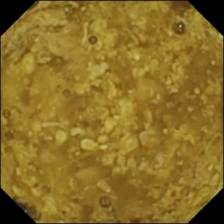

In [14]:
unnormalized_image = (pixel_values.numpy() * np.array(std)[:, None, None]) + np.array(mean)[:, None, None]
unnormalized_image = (unnormalized_image * 255).astype(np.uint8)
unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
Image.fromarray(unnormalized_image)

In [15]:
print("label ID :",labels)
s=torch.nonzero(labels).squeeze().tolist()
print(s)

label ID : tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
4


## **Create PyTorch DataLoader**

In [16]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    data = torch.stack([item[0] for item in batch])
    target = torch.stack([item[1] for item in batch])
    return data, target

train_dataloader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=16, shuffle=True)

In [17]:
batch = next(iter(train_dataloader))
#print(batch)

In [18]:
print(batch[0].shape)
print(batch[1].shape)

torch.Size([16, 3, 224, 224])
torch.Size([16, 17])


### **Verify initial loss**

In [21]:
# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


outputs = model(pixel_values=batch[0].to(device), labels=batch[1].to(device))

In [22]:
outputs.loss

tensor(0.6987, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

## **Training the model**

In [23]:
# handy utility I found at https://github.com/wenwei202/pytorch-examples/blob/ecbb7beb0fac13133c0b09ef980caf002969d315/imagenet/main.py#L296
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [24]:
from torch.optim import AdamW
from tqdm.auto import tqdm

# move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)

losses = AverageMeter()

model.train()
for epoch in range(6):  # loop over the dataset multiple times
    for idx, batch in enumerate(tqdm(train_dataloader)):
        # get the inputs;
        pixel_values, labels = batch

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(
            pixel_values=pixel_values.to(device),
            labels=labels.to(device),
        )

        # calculate gradients
        loss = outputs.loss
        losses.update(loss.item(), pixel_values.size(0))
        loss.backward()

        # optimization step
        optimizer.step()

        if idx % 100 == 0:
            print('Epoch: [{0}]\t'
                  'Loss {loss.val:.4f} ({loss.avg:.4f})\t'.format(
                   epoch, loss=losses,))
            
    # save model at each Epoch
    model_nm = f'fine_tuned_ep{epoch}.pth'
    torch.save(model, model_nm)

  0%|          | 0/2640 [00:00<?, ?it/s]

Epoch: [0]	Loss 0.6985 (0.6985)	
Epoch: [0]	Loss 0.3769 (0.4614)	
Epoch: [0]	Loss 0.3015 (0.3988)	
Epoch: [0]	Loss 0.2490 (0.3576)	
Epoch: [0]	Loss 0.2020 (0.3268)	
Epoch: [0]	Loss 0.1951 (0.3021)	
Epoch: [0]	Loss 0.1521 (0.2816)	
Epoch: [0]	Loss 0.1719 (0.2634)	
Epoch: [0]	Loss 0.1257 (0.2482)	
Epoch: [0]	Loss 0.1436 (0.2350)	
Epoch: [0]	Loss 0.1074 (0.2227)	
Epoch: [0]	Loss 0.0918 (0.2116)	
Epoch: [0]	Loss 0.0808 (0.2021)	
Epoch: [0]	Loss 0.0724 (0.1933)	
Epoch: [0]	Loss 0.0640 (0.1853)	
Epoch: [0]	Loss 0.0605 (0.1780)	
Epoch: [0]	Loss 0.0629 (0.1712)	
Epoch: [0]	Loss 0.0448 (0.1651)	
Epoch: [0]	Loss 0.0866 (0.1593)	
Epoch: [0]	Loss 0.0824 (0.1542)	
Epoch: [0]	Loss 0.0546 (0.1494)	
Epoch: [0]	Loss 0.0342 (0.1450)	
Epoch: [0]	Loss 0.0561 (0.1409)	
Epoch: [0]	Loss 0.0365 (0.1368)	
Epoch: [0]	Loss 0.0493 (0.1329)	
Epoch: [0]	Loss 0.0455 (0.1295)	
Epoch: [0]	Loss 0.0675 (0.1262)	


  0%|          | 0/2640 [00:00<?, ?it/s]

Epoch: [1]	Loss 0.0237 (0.1249)	
Epoch: [1]	Loss 0.0238 (0.1217)	
Epoch: [1]	Loss 0.0263 (0.1186)	
Epoch: [1]	Loss 0.0457 (0.1156)	
Epoch: [1]	Loss 0.0363 (0.1130)	
Epoch: [1]	Loss 0.0194 (0.1102)	
Epoch: [1]	Loss 0.0285 (0.1077)	
Epoch: [1]	Loss 0.0237 (0.1053)	
Epoch: [1]	Loss 0.0233 (0.1031)	
Epoch: [1]	Loss 0.0273 (0.1009)	
Epoch: [1]	Loss 0.0193 (0.0990)	
Epoch: [1]	Loss 0.0465 (0.0971)	
Epoch: [1]	Loss 0.0165 (0.0952)	
Epoch: [1]	Loss 0.0127 (0.0935)	
Epoch: [1]	Loss 0.0172 (0.0918)	
Epoch: [1]	Loss 0.0124 (0.0902)	
Epoch: [1]	Loss 0.0192 (0.0886)	
Epoch: [1]	Loss 0.0146 (0.0871)	
Epoch: [1]	Loss 0.0206 (0.0857)	
Epoch: [1]	Loss 0.0165 (0.0843)	
Epoch: [1]	Loss 0.0094 (0.0829)	
Epoch: [1]	Loss 0.0363 (0.0816)	
Epoch: [1]	Loss 0.0116 (0.0804)	
Epoch: [1]	Loss 0.0435 (0.0792)	
Epoch: [1]	Loss 0.0062 (0.0780)	
Epoch: [1]	Loss 0.0107 (0.0769)	
Epoch: [1]	Loss 0.0126 (0.0757)	


  0%|          | 0/2640 [00:00<?, ?it/s]

...

  0%|          | 0/2640 [00:00<?, ?it/s]

Epoch: [4]	Loss 0.0042 (0.0434)	
Epoch: [4]	Loss 0.0012 (0.0430)	
Epoch: [4]	Loss 0.0029 (0.0427)	
Epoch: [4]	Loss 0.0082 (0.0423)	
Epoch: [4]	Loss 0.0102 (0.0420)	
Epoch: [4]	Loss 0.0018 (0.0416)	
Epoch: [4]	Loss 0.0025 (0.0413)	
Epoch: [4]	Loss 0.0014 (0.0410)	
Epoch: [4]	Loss 0.0009 (0.0406)	
Epoch: [4]	Loss 0.0046 (0.0403)	
Epoch: [4]	Loss 0.0026 (0.0401)	
Epoch: [4]	Loss 0.0015 (0.0398)	
Epoch: [4]	Loss 0.0015 (0.0395)	
Epoch: [4]	Loss 0.0014 (0.0392)	
Epoch: [4]	Loss 0.0015 (0.0389)	
Epoch: [4]	Loss 0.0021 (0.0387)	
Epoch: [4]	Loss 0.0014 (0.0385)	
Epoch: [4]	Loss 0.0025 (0.0382)	
Epoch: [4]	Loss 0.0011 (0.0379)	
Epoch: [4]	Loss 0.0106 (0.0377)	
Epoch: [4]	Loss 0.0020 (0.0375)	
Epoch: [4]	Loss 0.0042 (0.0373)	
Epoch: [4]	Loss 0.0071 (0.0370)	
Epoch: [4]	Loss 0.0020 (0.0368)	
Epoch: [4]	Loss 0.0026 (0.0365)	
Epoch: [4]	Loss 0.0009 (0.0363)	
Epoch: [4]	Loss 0.0037 (0.0361)	


  0%|          | 0/2640 [00:00<?, ?it/s]

Epoch: [5]	Loss 0.0017 (0.0360)	


KeyboardInterrupt: 

### Save Model

In [23]:
import torch

# Assuming 'model' is your PyTorch model
# Save the entire model
#torch.save(model, 'fine_tuned_vit-base-patch16-224-in21k_10Mar26.pth')

# Or save only the model state dictionary
#torch.save(model.state_dict(), 'fine_tuned_vit-base-patch16-224-in21k_state_dict_10Mar26.pth')

### Load saved model

In [25]:
import torch

# Load the entire model
#model_save = torch.load('fine_tuned_vit-base-patch16-224-in21k_10Mar26.pth')
model_save = torch.load('fine_tuned_ep4.pth')

# Move the model to the appropriate device if necessary
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

## **Inference**

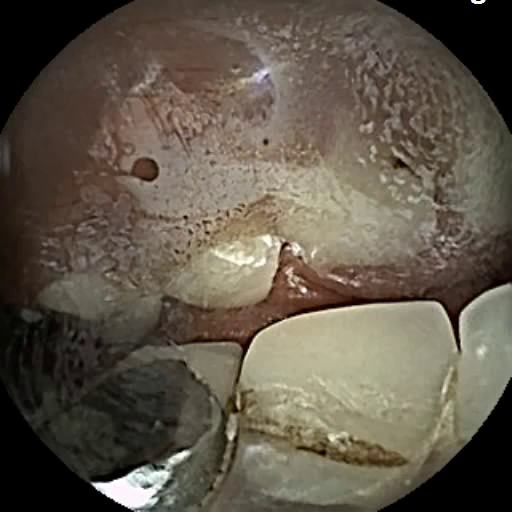

lable= [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [26]:
# load image to test on
image = Image.open(test_paths[5][0])
display(image)
print('lable=', test_labels[5])

In [27]:
model_save.eval()

# prepare image for the model
pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

# forward pass
with torch.no_grad():
  outputs = model_save(pixel_values)
  logits = outputs.logits


In [28]:
# turn into probabilities by applying sigmoid
sigmoid = torch.nn.Sigmoid()
probs = sigmoid(logits.squeeze().cpu())
print(probs)
# select the probabilities > a certain threshold (e.g. 50%) as predicted
predictions = np.zeros(probs.shape)
print(predictions)
predictions[np.where(probs >= 0.5)] = 1 # turn predicted id's into actual label names
print(predictions)
predicted_labels = [id2label[idx] for idx, label in enumerate(predictions) if label == 1.0]
print(predicted_labels)

tensor([9.9789e-01, 7.2535e-05, 7.7698e-04, 1.9890e-03, 2.0521e-03, 4.4634e-05,
        5.2312e-04, 2.1513e-04, 1.7319e-04, 4.8728e-04, 4.2753e-04, 2.0709e-04,
        3.4097e-04, 8.2837e-04, 4.3724e-04, 2.7185e-04, 4.4903e-04])
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
['mouth']
